# Preprocessing for Anomaly Detection in Mobile Networks

This notebook describes the preprocessing stage for drive test data used in the downstream anomaly-detection pipeline.

**Target audience:** telecom engineers and PhD students  
**Dataset assumption:** `datasets/d2_Operator1_CapacityDL.csv`

## Learning objectives
1. Load the raw dataset in a reproducible way.
2. Provide a consistent feature-naming convention.
3. Extract relevant features for network throughput analysis
4. Apply standard data cleaning techniques
5. Detect and mitigate multicollinearity
6. Perform advanced feature selection via correlation clustering
7. Summarize and visualize clean data


## Notebook flow
1. Environment setup  
2. Load the raw dataset  
3. Standardize feature names
4. Manual selection of relevant variables for anomaly detection
5. Simple data preprocessing
6. Multicollinearity detection and removal
7. Correlation-based feature pruning via Gaussian mixtures and BIC
8. Statistical summary of the cleaned dataset

## 1. Environment Setup

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Our functions
from srcs.preprocessing_functions import vif_prune, bic_grid
from srcs.preprocessing_functions import best_gmm_by_bic, compute_stat_summary
from srcs.plot_functions import plot_bic_and_clusters, plot_feature_scatter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Raw Dataset

The dataset is read from the local `datasets/` directory.  A copy of the raw dataframe is preserved so the preprocessing logic remains auditable.

In [2]:
DATA_FILE = "d2_Operator1_CapacityDL"
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data_raw = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Raw dataset shape: {data_raw.shape[0]:,} rows x {data_raw.shape[1]:,} columns")
display(data_raw.head())

Raw dataset shape: 1,001 rows x 624 columns


,unnamed:.0,transfer.datarate,transfer.duration,total.packets.a2b,total.packets.b2a,resets.sent.a2b,resets.sent.b2a,ack.pkts.sent.a2b,pure.acks.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.a2b,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,unique.bytes.sent.a2b,unique.bytes.sent.b2a,actual.data.pkts.a2b,actual.data.pkts.b2a,actual.data.bytes.a2b,actual.data.bytes.b2a,rexmt.data.pkts.a2b,rexmt.data.pkts.b2a,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,pushed.data.pkts.a2b,pushed.data.pkts.b2a,sacks.sent.a2b,max.segm.size.a2b,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,avg.segm.size.b2a,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,avg.win.adv.b2a,max.owin.a2b,max.owin.b2a,min.non.zero.owin.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,wavg.owin.b2a,initial.window.bytes.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,truncated.data.b2a,truncated.packets.a2b,truncated.packets.b2a,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.a2b,idletime.max.b2a,throughput.a2b,throughput.b2a,rtt.samples.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,rtt.full.sz.avg.a2b,rtt.min.last.a2b,rtt.max.last.a2b,rtt.avg.last.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,max.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,syn.pkts.sent.a2b,fin.pkts.sent.a2b,ambiguous.acks.a2b,rtt.samples.b2a,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.a2b,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.25.,abs.downlinkdelay.50.,abs.downlinkdelay.avg,abs.downlinkdelay.75.,abs.downlinkdelay.max,abs.downlinkdelay.firstmb,abs.downlinkdelay.firstsec,abs.downlinkdelay.volstep.30kb,abs.downlinkdelay.volstep.90kb,abs.downlinkdelay.volstep.240kb,abs.downlinkdelay.volstep.630kb,abs.downlinkdelay.volstep.1650kb,abs.downlinkdelay.volstep.4320kb,abs.downlinkdelay.volstep.11310kb,abs.downlinkdelay.volstep.29610kb,abs.downlinkdelay.volstep.77520kb,abs.downlinkdelay.volstep.202950kb,abs.downlinkdelay.volstep.531330kb,abs.downlinkdelay.timestep.40ms,abs.downlinkdelay.timestep.80ms,abs.downlinkdelay.timestep.160ms,abs.downlinkdelay.timestep.320ms,abs.downlinkdelay.timestep.640ms,abs.downlinkdelay.timestep.1280ms,abs.downlinkdelay.timestep.2560ms,abs.downlinkdelay.timestep.5120ms,abs.downlinkdelay.timestep.10240ms,abs.downlinkdelay.timestep.20480ms,abs.uplinkdelay.min,abs.uplinkdelay.25.,abs.uplinkdelay.50.,abs.uplinkdelay.avg,abs.uplinkdelay.75.,abs.uplinkdelay.max,abs.uplinkdelay.firstmb,abs.uplinkdelay.firstsec,abs.uplinkdelay.volstep.30kb,abs.uplinkdelay.volstep.90kb,abs.uplinkdelay.volstep.240kb,abs.uplinkdelay.volstep.630kb,abs.uplinkdelay.volstep.1650kb,abs.uplinkdelay.volstep.4320kb,abs.uplinkdelay.volstep.11310kb,abs.uplinkdelay.volstep.29610kb,abs.uplinkdelay.volstep.77520kb,abs.uplinkdelay.volstep.202950kb,abs.uplinkdelay.volstep.531330kb,abs.uplinkdelay.timestep.40ms,abs.uplinkdelay.timestep.80ms,abs.uplinkdelay.timestep.160ms,abs.uplinkdelay.timestep.320ms,abs.uplinkdelay.timestep.640ms,abs.uplinkdelay.timestep.1280ms,abs.uplinkdelay.timestep.2560ms,abs.uplinkdelay.timestep.5120ms,abs.uplinkdelay.timestep.10240ms,abs.uplinkdelay.timestep.20480ms,abs.downlinkdeltadelay.25.,abs.downlinkdeltadelay.50.,abs.downlinkdeltadelay.avg,abs.downlinkdeltadelay.75.,abs.downlinkdeltadelay.max,abs.downlinkdeltadelay.firstmb,abs.downlinkdeltadelay.firstsec,abs.downlinkdeltadelay.volstep.30kb,abs.downlinkdeltadelay.volstep.90kb,abs.downlinkdeltadelay.volstep.240kb,abs.downlinkdeltadelay.volstep.630kb,abs.do

## 3. Standardize Feature Names

Drive test datasets export often mix cases, spaces, underscores, and punctuation.  Before any filtering, column names are normalized to a **lowercase dot-separated convention**.  This reduces ambiguity in downstream notebooks and reports.

In [3]:
def standardize_column_name(name: str) -> str:
    """Convert raw column names to lowercase dot-separated identifiers."""
    name = name.lower().strip()
    name = re.sub(r"[^0-9a-z]+", ".", name)
    name = re.sub(r"\.+", ".", name).strip(".")
    return name


column_name_map = {column: standardize_column_name(column) for column in data_raw.columns}
data = data_raw.rename(columns=column_name_map).copy()

column_preview = pd.DataFrame(
    {
        "original_name": list(column_name_map.keys())[:12],
        "normalized_name": list(column_name_map.values())[:12],
    }
)

print("Column names standardized successfully.")
display(column_preview)

Column names standardized successfully.


,original_name,normalized_name
0,unnamed:.0,unnamed.0
1,transfer.datarate,transfer.datarate
2,transfer.duration,transfer.duration
3,total.packets.a2b,total.packets.a2b
4,total.packets.b2a,total.packets.b2a
5,resets.sent.a2b,resets.sent.a2b
6,resets.sent.b2a,resets.sent.b2a
7,ack.pkts.sent.a2b,ack.pkts.sent.a2b
8,pure.acks.sent.a2b,pure.acks.sent.a2b
9,pure.acks.sent.b2a,pure.acks.sent.b2a


## 4. Manual Selection of Relevant Variables for Anomaly Detection

The selected variables include throughput and directional traffic indicators, along with standard summary statistics commonly used in anomaly analysis:

- Transfer data rate indicators
- Directional statistics (`a2b`, `b2a`)
- Distribution summaries (`min`, `25th percentile`, `median`, `75th percentile`, `max`, `average`, `sum`)

Initial and incremental fields such as `volstep`, `timestep`, `firstsec`, and `firstmb` are excluded from consideration. These variables were identified based on experience in mobile networks.

Duplicate features are removed, and the final dataset is converted to a numeric format for statistical profiling.

In [4]:
INCLUDE_PATTERNS = [
    r"transfer\.datarate",
    r"\.a2b(\.|$)",
    r"\.b2a(\.|$)",
    r"\.min(\.|$)",
    r"\.25(\.|$)",
    r"\.50(\.|$)",
    r"\.75(\.|$)",
    r"\.max(\.|$)",
    r"\.avg(\.|$)",
    r"\.sum(\.|$)",
]


selected_mask = pd.Series(False, index=data.columns)
for pattern in INCLUDE_PATTERNS:
    selected_mask |= data.columns.str.contains(pattern, regex=True, na=False)

selected_data = data.loc[:, selected_mask].copy()
columns_after_exclusion = selected_data.shape[1]

selected_data = selected_data.loc[:, ~selected_data.columns.duplicated()].copy()
selected_data = selected_data.T.drop_duplicates().T

duplicate_features_removed = columns_after_exclusion - selected_data.shape[1]

data = (
    selected_data
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

selection_report = pd.DataFrame(
    {
        "metric": [
            "Features of the raw dataset",
            "Candidate features matching AD analysis",
            "Features after exclusion rules",
            "Duplicate features removed",
            "Final retained features",
        ],
        "value": [
            len(data_raw.columns),
            int(selected_mask.sum()),
            columns_after_exclusion,
            duplicate_features_removed,
            data.shape[1],
        ],
    }
)

print(f"Prepared dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(selection_report)
display(data.head())

Prepared dataset shape: 1,001 rows x 189 columns


,metric,value
0,Features of the raw dataset,624
1,Candidate features matching AD analysis,189
2,Features after exclusion rules,189
3,Duplicate features removed,0
4,Final retained features,189


,transfer.datarate,total.packets.a2b,total.packets.b2a,resets.sent.a2b,resets.sent.b2a,ack.pkts.sent.a2b,pure.acks.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.a2b,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,unique.bytes.sent.a2b,unique.bytes.sent.b2a,actual.data.pkts.a2b,actual.data.pkts.b2a,actual.data.bytes.a2b,actual.data.bytes.b2a,rexmt.data.pkts.a2b,rexmt.data.pkts.b2a,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,pushed.data.pkts.a2b,pushed.data.pkts.b2a,sacks.sent.a2b,max.segm.size.a2b,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,avg.segm.size.b2a,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,avg.win.adv.b2a,max.owin.a2b,max.owin.b2a,min.non.zero.owin.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,wavg.owin.b2a,initial.window.bytes.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,truncated.data.b2a,truncated.packets.a2b,truncated.packets.b2a,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.a2b,idletime.max.b2a,throughput.a2b,throughput.b2a,rtt.samples.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,rtt.full.sz.avg.a2b,rtt.min.last.a2b,rtt.max.last.a2b,rtt.avg.last.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,max.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,syn.pkts.sent.a2b,fin.pkts.sent.a2b,ambiguous.acks.a2b,rtt.samples.b2a,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.a2b,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.25,abs.downlinkdelay.50,abs.downlinkdelay.avg,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.min,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.downlinkdeltadelay.50,abs.downlinkdeltadelay.avg,abs.downlinkdeltadelay.75,abs.downlinkdeltadelay.max,abs.uplinkdeltadelay.25,abs.uplinkdeltadelay.50,abs.uplinkdeltadelay.avg,abs.uplinkdeltadelay.75,abs.uplinkdeltadelay.max,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.avg,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.avg,abs.segmentsizes.75,abs.segmentsizes.max,abs.packetlost.sum,abs.pushevents.sum,abs.instanttp.min,abs.instanttp.25,abs.instanttp.50,abs.instanttp.avg,abs.instanttp.75,abs.instanttp.max,abs.burst.sum,abs.burstsizes.min,abs.burstsizes.25,abs.burstsizes.50,abs.burstsizes.avg,abs.burstsizes.75,abs.burstsizes.max,abs.rtoevents.sum,abs.theoricalmaxtp.min,abs.theoricalmaxtp.25,abs.theoricalmaxtp.50,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.75,abs.theoricalmaxtp.max
0,448375.109,24732.0,42390.0,100.0,0.0,24629.0,24619.0,8.0,43.0,0.0,43.0,1160.0,404736418.0,5.0,42377.0,1160.0,405175766.0,0.0,43.0,0.0,439348.0,17.0,5.0,14030.0,43.0,232.0,65236.0,232.0,4.0,231.0,9459.4,41937920.0,1946752.0,1638400.0,40000544.0,1946634.0,1165.0,3.522698e+06,5.0,5.0,5.0,153524.0,5.0,1.543933e+05,1160.0,24984.0,9.0,460.0,405080042.0,5.0,42375.0,0.0,7.328,265.2,264.8,155.0,54793453.0,2.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,5455.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,

## 5. Simple data Preprocessing

Before applying anomaly detection methods, we ensure that the dataset is **numerically stable and statistically meaningful**.

### Key Steps:
- **Target KPI selection**: Focus on a critical metric (`transfer.datarate`)
- **Handling infinities**: Replace invalid values with NaN
- **Missing data filtering**:
  - Remove features with >1% missing values
  - Impute remaining missing values using **median (robust)**
- **Feature cleaning**:
  - Remove constant (non-informative) features

### Why this matters:
- Datasets often contain **missing values due to outages or reporting issues**
- Heavy-tailed behavior makes **median imputation more robust than mean (furthermore, median is a sample-based metric)**
- Constant variables (e.g., inactive counters) add **noise to anomaly detection models**

In [5]:
# Replace infinite values with NaN
data = data.replace([np.inf, -np.inf], np.nan)

# Remove columns with more than 1% missing values
data = data.loc[:, data.isna().mean(axis=0) < 0.01]

# Fill remaining missing values using median (robust to outliers)
data = data.fillna(data.median(axis=0))

# Remove constant (zero-variance) columns
data = data.loc[:, data.std(axis=0) != 0]

print(f"Data shape after preprocessing: {data.shape}")

Data shape after preprocessing: (1001, 180)


## 6. Multicollinearity Detection and Removal

In high-dimensional data, many features are **strongly correlated**. This can lead to:

- Unstable anomaly scores
- Redundant information
- Poor model interpretability  
- Numerical instability in statistical methods

### What is VIF?

The **Variance Inflation Factor (VIF)** measures how much the variance of a feature is inflated due to correlation with other features.

- VIF = 1 → no correlation  
- VIF > 10 → strong multicollinearity  
- VIF >> 10 → severe redundancy  

### Approach Used Here

Instead of fitting one regression per feature (slow), we compute VIF using:

- The **inverse of the correlation matrix**
- A **pseudo-inverse** to handle singularity

### Pruning Strategy

We iteratively:
1. Compute VIF for all features  
2. Remove the feature with the **highest VIF**  
3. Repeat until all VIF values are below a threshold  

### Why this matters in network data:

- KPIs in drive test data are often **structurally coupled**
- Reducing multicollinearity improves robust anomaly detection

Data shape after VIF pruning: (1001, 133)
Columns dropped due to high VIF (> 1000): ['unique.bytes.sent.b2a', 'abs.theoricalmaxtp.min', 'pure.acks.sent.a2b', 'total.packets.b2a', 'abs.uplinkdeltadelay.50', 'abs.uplinkdelay.min', 'abs.downlinkdeltadelay.max', 'abs.uplinkdeltadelay.max', 'abs.uplinkdeltadelay.25', 'abs.downlinkdeltadelay.75', 'abs.uplinkdeltadelay.75', 'abs.downlinkdelay.avg', 'abs.downlinkdeltadelay.50', 'sack.pkts.sent.a2b', 'initial.window.bytes.a2b', 'abs.downlinkdelay.25', 'actual.data.bytes.a2b', 'total.packets.a2b', 'max.segm.size.a2b', 'truncated.packets.b2a', 'rtt.min.last.a2b', 'truncated.data.b2a', 'avg.win.adv.b2a', 'max.retr.time.a2b', 'rtt.max.last.a2b', 'rtt.avg.last.a2b', 'syn.pkts.sent.a2b', 'min.non.zero.owin.a2b', 'pushed.data.pkts.a2b', 'ambiguous.acks.a2b', 'rexmt.data.pkts.a2b', 'max.owin.a2b', 'actual.data.pkts.a2b', 'truncated.packets.a2b', 'rexmt.data.pkts.b2a', 'actual.data.pkts.b2a', 'throughput.b2a', 'abs.instanttp.avg', 'rtt.samples.a2b', 'un

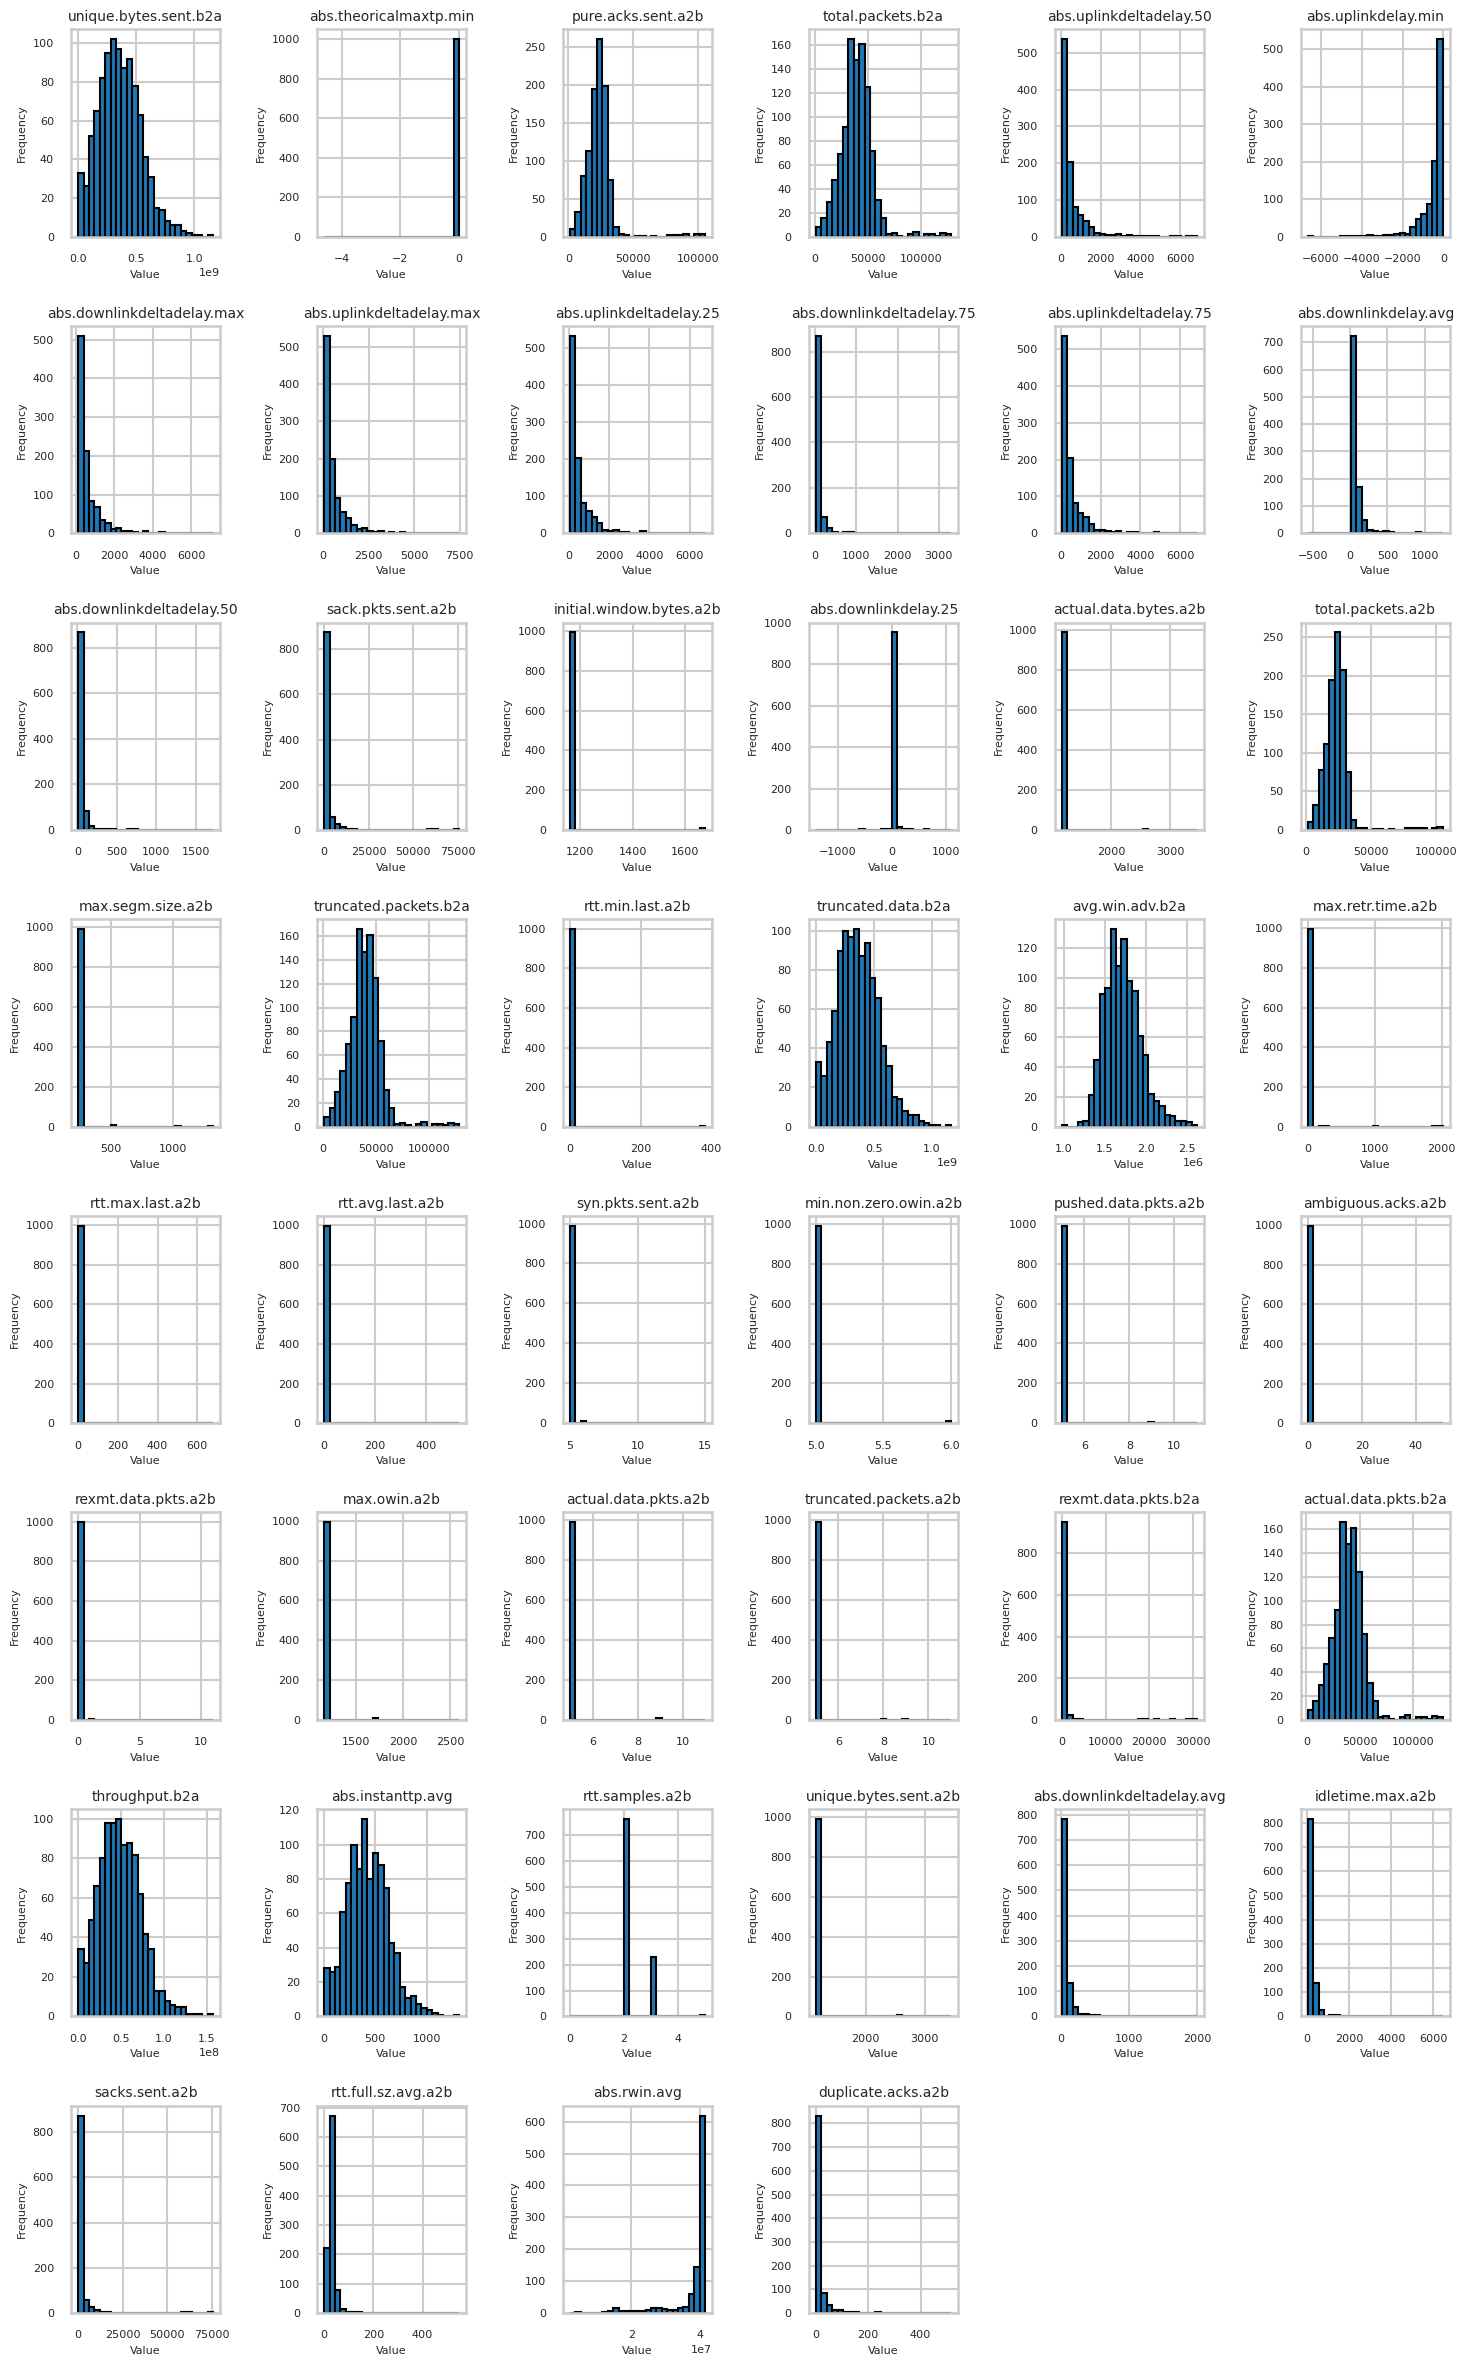

In [6]:
# Target KPI selection
target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
data = data.drop(columns=[target_kpi])

VIF_MAX_THRESHOLD = 1000
data_vif_pruned, columns_dropped_due_to_vif = vif_prune(data, vif_max=VIF_MAX_THRESHOLD)
print(f"Data shape after VIF pruning: {data_vif_pruned.shape}")
print(f"Columns dropped due to high VIF (> {VIF_MAX_THRESHOLD}): {columns_dropped_due_to_vif}")
data_vif_pruned[target_kpi] = kpi_aux

n_cols = 6
n_rows = int(np.ceil(len(columns_dropped_due_to_vif) / n_cols))

plt.figure(figsize=(15, 3 * n_rows))

for i, col in enumerate(columns_dropped_due_to_vif, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(data[col], bins=25, color='tab:blue', edgecolor='black')
    plt.title(col, fontsize=10)
    plt.xlabel("Value", fontsize=8)
    plt.ylabel("Frequency", fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=8)
    plt.gca().xaxis.get_offset_text().set_fontsize(8)

plt.tight_layout()
plt.show()

## 7. Correlation-Based Feature Pruning via Gaussian Mixtures and BIC

After removing multicollinearity (VIF), we further refine the feature space by identifying **highly correlated KPI groups** using a **model-based clustering approach**.

### Objective

Group features based on their **correlation with a target KPI** (`transfer.datarate`) and remove **redundant clusters** while preserving the most informative variables.

### Key Idea

Instead of applying a fixed correlation threshold, we:

1. Transform correlations with respect to the target KPI into a **distance-like metric**:
   - `distance = 1 - |correlation|`
2. Cluster features using a **Gaussian Mixture Model (GMM) on computed distances**
3. Automatically determine the **optimal number of clusters** using **BIC (Bayesian Information Criterion)**
4. Remove the cluster with features highly correlated with the KPI

### Monte Carlo BIC Optimization

To ensure robustness:

- We evaluate multiple GMM initializations (random seeds)
- For each number of clusters \( k \), we compute BIC across iterations
- We select:
  - The **optimal k** minimizing average BIC
  - The **best model** (lowest BIC across seeds)
- This avoids unstable clustering due to random initialization

### Feature Selection Strategy

Once clusters are identified:

- Each feature belongs to a correlation cluster
- We:
  - Identify the cluster with **lowest centroid (lowest distances with respect to the target KPI and strongest correlations)**
  - Remove features from that cluster
- Restore the target KPI to ensure consistency

### Output

- Cleaned dataset saved to:
  `datasets/data_clean.csv`

Saved data_clean.csv with 120 features (after high-correlation pruning)


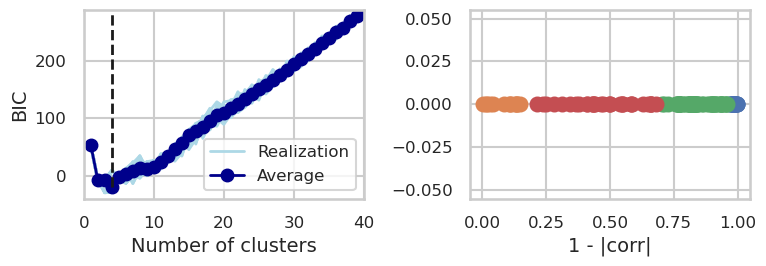

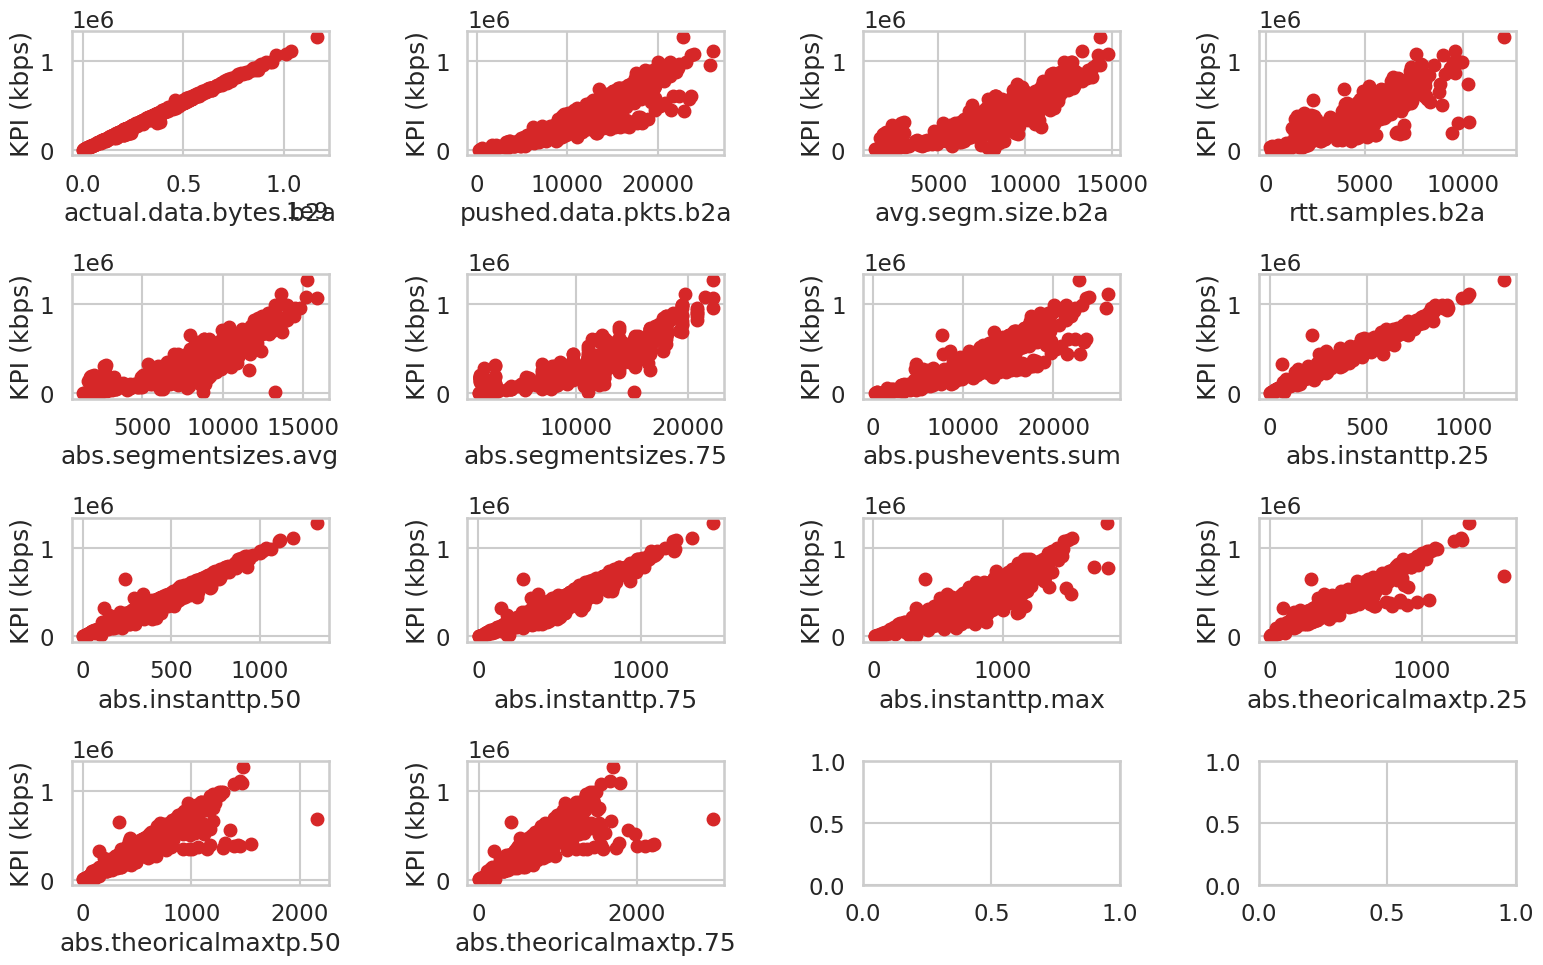

In [7]:
corr_matrix = 1 - data_vif_pruned.corr(method='pearson').abs()
# corr_vector = corr_matrix[target_kpi].to_numpy().reshape(-1,1)
corr_vector = corr_matrix[target_kpi]
corr_vector = corr_vector.drop(index=target_kpi).to_numpy().reshape(-1, 1)

EVAL_WINDOW = 40
BIC_ITERATIONS  = 50
RANDOM_STATE = 42
max_num_clusters = np.min([EVAL_WINDOW + 1, len(corr_vector)])
bic_ite, seeds = bic_grid(corr_vector, max_k=max_num_clusters, iterations=BIC_ITERATIONS, seed=RANDOM_STATE)
# Determining the optimal number of clusters
num_opt_clusters_bic = np.argmin(np.mean(bic_ite, axis=0)) + 1
best = best_gmm_by_bic(corr_vector, k=num_opt_clusters_bic, seeds=seeds[:, num_opt_clusters_bic - 1])
clusters_bic = best.predict(corr_vector)
centroids_bic = best.means_

data_cleaned = data_vif_pruned.copy()
data_vif_pruned = data_vif_pruned.loc[:, data_vif_pruned.columns != target_kpi]
data_cleaned = data_cleaned.loc[:, data_cleaned.columns != target_kpi]
if (len(np.unique(clusters_bic)) > 1):
    data_cleaned = data_cleaned.loc[:, data_cleaned.columns[(clusters_bic != np.argmin(centroids_bic))]]
data_cleaned[target_kpi] = kpi_aux

OUT_FILE = "data_clean"
OUT_PATH = Path("datasets") / f"{OUT_FILE}.csv"

data_cleaned.to_csv(OUT_PATH, index=False)
print(f"Saved {OUT_FILE}.csv with {data_cleaned.shape[1]} features (after high-correlation pruning)")

plot_bic_and_clusters(bic_ite, 
                          BIC_ITERATIONS, 
                          max_num_clusters, 
                          num_opt_clusters_bic, 
                          corr_vector, 
                          clusters_bic)
columns_to_remove_bic = data_vif_pruned.columns[(clusters_bic == np.argmin(centroids_bic))]
plot_feature_scatter(data_vif_pruned, kpi_aux, columns_to_remove_bic, ncols= 4)

## 8. Statistical Summary of Cleaned KPI Dataset

After preprocessing (missing values, VIF pruning, correlation clustering), we compute a **comprehensive statistical summary** of the cleaned dataset.

### Summary Metrics (per KPI)

We compute the following statistics for each feature:

- **Minimum / Maximum** → range boundaries  
- **Quartiles (Q1, Median, Q3)** → distribution shape  
- **Mean** → central tendency (non-robust)  
- **Variance / Standard Deviation** → dispersion  
- **Coefficient of Variation (CV)** → normalized variability  
- **Range** → spread (max − min)  
- **Median Absolute Deviation (MAD)** → robust dispersion
- **Skewness**
- **Kurtosis**

### Why this matters in telecom data:

- KPIs often exhibit:
  - **Heavy tails**
  - **Skewness**
- Mean and variance alone are insufficient  
- Robust metrics provide stable insights under anomalies

### Goal

This summary allows us to:

- Understand **feature distributions**
- Detect **scale differences across KPIs**
- Identify **unstable or highly variable signals**
- Prepare for **robust anomaly detection models**

In [8]:
# Compute summary
stat_summary = compute_stat_summary(data_cleaned)

# Display
print("Statistical summary shape:", stat_summary.shape)
stat_summary.head(13)

Statistical summary shape: (13, 120)


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
min,0.000000,1.299000e+03,5.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,5.308000e+03,64.000000,1.000000,231.000000,5.317632e+06,9.766400e+05,1.638400e+06,2.979924e+06,5.000000,5.000000,1.718100e+04,0.000000,9.820000e+03,5.000000,460.000000,0.000000,7.025000,28.100000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.400000,0.200000,0.400000,0.300000,1.000000,0.100000,0.300000,0.300000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000e+00,-1696.000000,-1227.500000,-810.000000,118.000000,-1839.000000,-223.000000,-976.717931,7.000000,21.000000,6.000000,37.983464,0.000000,15.000000,20.000000,24.805608,24.000000,131.000000,-2.198500e+05,9.258000e+04,1.107520e+05,1.107702e+05,1.333240e+05,2.348720e+05,1.087488e+06,2.285568e+06,3.059712e+06,4.113408e+06,-0.005638,0.009546,0.015185,0.021819,0.019362,0.108008,0.000000,0.000000e+00,0.000000e+00,5.494365e+04,0.000000e+00,6.949160e+05,0.000000,0.065757,0.000000,13.000000,0.000000,660.000000,1.327000e+03,5.538000e+03,0.000000,8.000000e-05,0.000000,0.000000e+00,2.317959e+00,9.010940e+00,2.408967e+03
q1,62.000000,1.835700e+04,6.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,3.200000e+01,6.523600e+04,232.000000,3.000000,231.000000,4.075725e+07,1.563264e+06,1.638400e+06,3.751695e+07,5.000000,5.000000,1.426960e+05,0.000000,2.359600e+04,7.000000,460.000000,0.000000,7.289000,101.000000,155.000000,15.100000,26.200000,23.000000,0.000000,21.100000,1.000000,16.900000,22.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.400000,0.700000,0.600000,1.000000,0.200000,0.600000,0.600000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.297200e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

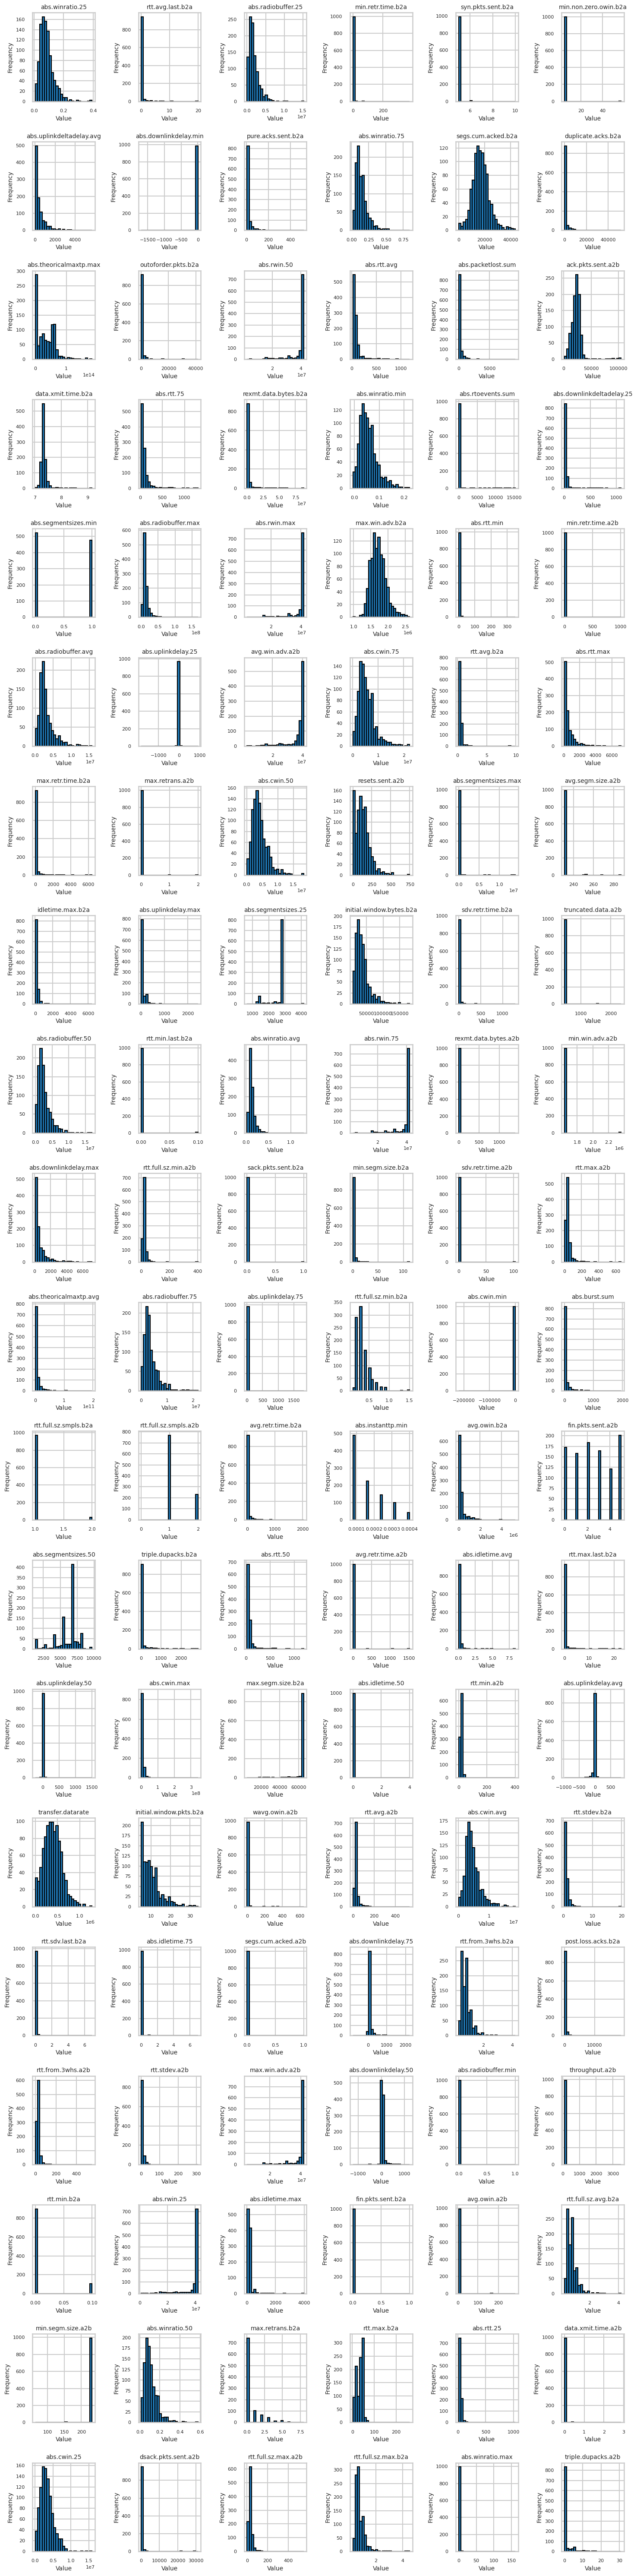

In [9]:
data_cleaned_columns = set(data_cleaned.columns)
n_cols = 6
n_rows = int(np.ceil(len(data_cleaned_columns) / n_cols))

plt.figure(figsize=(15, 3 * n_rows))

for i, col in enumerate(data_cleaned_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(data_cleaned[col], bins=25, color='tab:blue', edgecolor='black')
    plt.title(col, fontdict={"fontsize": 10})
    plt.xlabel("Value", fontdict={"fontsize": 10})
    plt.ylabel("Frequency", fontdict={"fontsize": 10})
    plt.tick_params(axis='both', which='major', labelsize=8)
    plt.gca().xaxis.get_offset_text().set_fontsize(8)

plt.tight_layout()
plt.show()